In [5]:
# Ignore sklearn convergence warnings
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [6]:
import os
print(os.getcwd())

C:\Users\User\Documents\confidence reliability


In [7]:
# Load dataset
import pandas as pd
df = pd.read_csv("data/adult.csv")
print(df.shape)
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.head()
# Missing values & class balance
print("\nMissing values:\n", df.isnull().sum())
print("\nIncome distribution:\n", df['income'].value_counts())

(48842, 15)
Shape: (48842, 15)

Columns:
 Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

Missing values:
 age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Income distribution:
 income
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [8]:
# DATA PREPROCESSING
# Convert income labels from text to numbers
# <=50K → 0 (low income)
# >50K  → 1 (high income)
df['income'] = df['income'].map({'<=50K':0, '>50K':1})

# Replace '?' values with missing (NaN) and remove those rows
# Dataset contains unknown entries marked as '?'
df = df.replace('?', pd.NA).dropna()

# Check new dataset size after cleaning
print("After cleaning shape:", df.shape)

# ONE-HOT ENCODING (CONVERT TEXT COLUMNS TO NUMERIC)
# Separate features (X) and target (y)
X = df.drop('income', axis=1)   # all input columns
y = df['income']                # output column

# Convert categorical text columns into numeric columns
# Example: workclass=Private → workclass_Private = 1
X = pd.get_dummies(X)

# Show new feature size after encoding
print("Encoded feature shape:", X.shape)  # Separate features (X) and target (y)
X = df.drop('income', axis=1)   # all input columns
y = df['income']                # output column

# Convert categorical text columns into numeric columns
# Example: workclass = Private → workclass_Private = 1
X = pd.get_dummies(X)

# Show new feature size after encoding
print("Encoded feature shape:", X.shape)

from sklearn.model_selection import train_test_split

# TRAIN_TEST_SPLIT
# Split data:
# 80% for training
# 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,  # ensures same split every run
    stratify=y)        # keeps same class ratio

# Print dataset sizes
print("Train:", X_train.shape)
print("Test :", X_test.shape)

After cleaning shape: (45222, 15)
Encoded feature shape: (45222, 104)
Encoded feature shape: (45222, 104)
Train: (36177, 104)
Test : (9045, 104)


In [9]:
# TRAIN BASELINE MODEL
# Import model and evaluation metric
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create Logistic Regression model
# max_iter increased so training always converges
model = LogisticRegression(max_iter=5000)

# Train model using training data
model.fit(X_train, y_train)

# Predict probabilities for test data
# Example output: [0.2, 0.8] → model 80% confident class 1
probs = model.predict_proba(X_test)

# Convert probabilities to predicted class labels
# chooses the highest probability class
preds = probs.argmax(axis=1)

# Calculate accuracy
accuracy = accuracy_score(y_test, preds)
print("Baseline Accuracy:", accuracy)

Baseline Accuracy: 0.8392482034273079


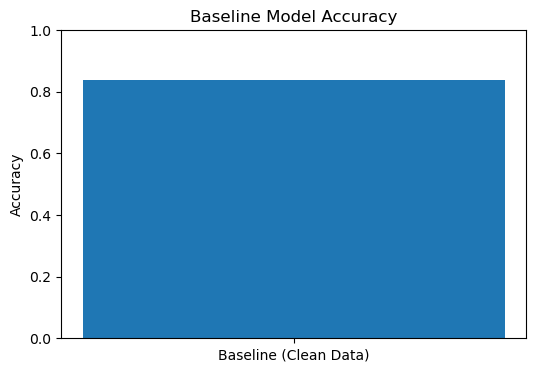

In [10]:
# PLOTTING BASLINE MODEL ACCURACY
import matplotlib.pyplot as plt

# Store baseline accuracy
baseline_accuracy = accuracy

plt.figure(figsize=(6,4))
plt.bar(["Baseline (Clean Data)"], [baseline_accuracy])

plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Baseline Model Accuracy")

# Save image for report
plt.savefig("Baseline_Accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

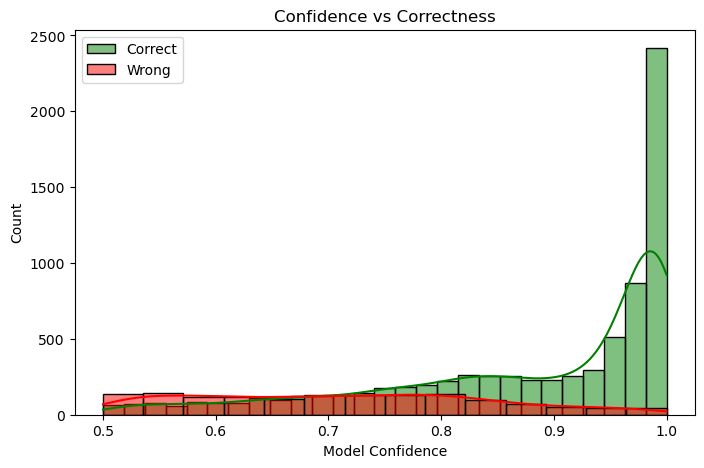

In [11]:
# CONFIDENCE VS CORRECTNESS
# CREATE RELIABILITY DATA
# Confidence = highest probability predicted by the model
confidence = probs.max(axis=1)

# Check whether prediction is correct (1) or wrong (0)
correct = (preds == y_test).astype(int)

# Create dataframe for analysis
import pandas as pd
results = pd.DataFrame({
    "confidence": confidence,
    "correct": correct})

# Preview
results.head()


# PLOT CONFIDENCE DISTRIBUTION
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Confidence of correct predictions
sns.histplot(results[results.correct==1]['confidence'],color="green", label="Correct", kde=True)
             
# Confidence of wrong predictions
sns.histplot(results[results.correct==0]['confidence'], color="red", label="Wrong", kde=True)
             
plt.legend()
plt.xlabel("Model Confidence")
plt.title("Confidence vs Correctness")
plt.savefig("Confidence Distribution – Correct vs Incorrect Predictions.png", dpi=300, bbox_inches="tight")
plt.show()


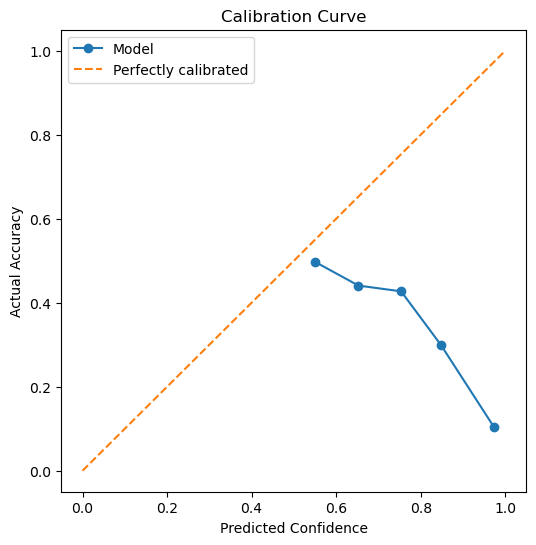

In [12]:
# CALIBRATION CURVE
# Import calibration tool
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Calculate calibration values
prob_true, prob_pred = calibration_curve(y_test, confidence, n_bins=10)

# Plot calibration curve
plt.figure(figsize=(6,6))

# Model curve
plt.plot(prob_pred, prob_true, marker='o', label="Model")

# Perfect calibration line
plt.plot([0,1],[0,1],'--', label="Perfectly calibrated")

plt.xlabel("Predicted Confidence")
plt.ylabel("Actual Accuracy")
plt.title("Calibration Curve")
plt.legend()
plt.savefig("Calibration Curve.png", dpi=300, bbox_inches="tight")
plt.show()

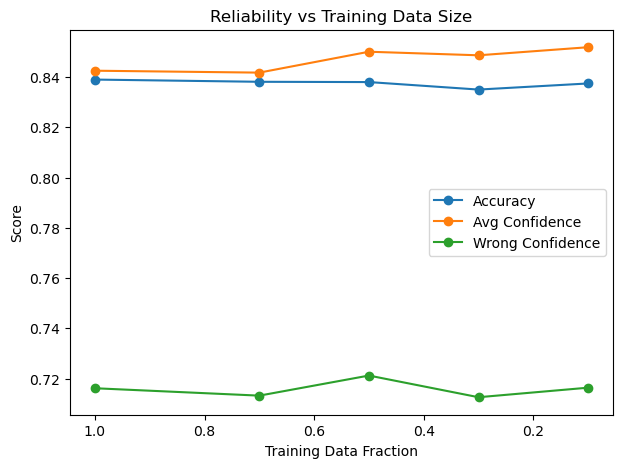

In [13]:
# SMALL DATA RELIABILITY EXPERIMENT
# RUN EXPERIMENT
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

sizes = [1.0, 0.7, 0.5, 0.3, 0.1]
records = []

for s in sizes:
    # Random subset of training data
    idx = np.random.choice(len(X_train), int(len(X_train)*s), replace=False)
    X_small = X_train.iloc[idx]
    y_small = y_train.iloc[idx]

    # Train new model
    m = LogisticRegression(max_iter=1000)
    m.fit(X_small, y_small)

    # Predict
    probs_s = m.predict_proba(X_test)
    preds_s = probs_s.argmax(axis=1)
    conf_s = probs_s.max(axis=1)
    accuracy_s = (preds_s == y_test).mean()
    avg_conf = conf_s.mean()
    wrong_conf = conf_s[preds_s != y_test].mean()
    records.append([s, accuracy_s, avg_conf, wrong_conf])

# Create results table
small_data_results = pd.DataFrame(records,columns=["Data Size","Accuracy","Avg Confidence","Wrong Confidence"])
small_data_results


# PLOT RELIABILITY EXPERIMENT
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(small_data_results["Data Size"], small_data_results["Accuracy"], marker='o', label="Accuracy")
plt.plot(small_data_results["Data Size"], small_data_results["Avg Confidence"], marker='o', label="Avg Confidence")
plt.plot(small_data_results["Data Size"], small_data_results["Wrong Confidence"], marker='o', label="Wrong Confidence")

plt.gca().invert_xaxis()
plt.xlabel("Training Data Fraction")
plt.ylabel("Score")
plt.title("Reliability vs Training Data Size")
plt.legend()
plt.savefig("Reliability vs Training Dta Size.png", dpi=300, bbox_inches="tight")
plt.show()

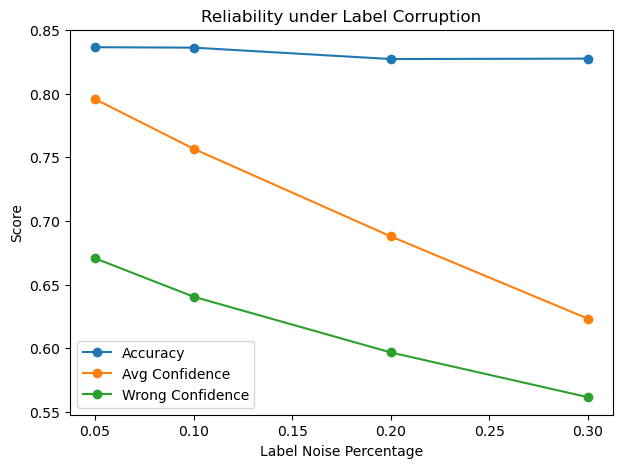

In [14]:
# LABEL NOISE RELIABILITY EXPERIMENT
# RUN LAB NOISE EXPERIMENT
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

noise_levels = [0.05, 0.10, 0.20, 0.30]
records = []

for noise in noise_levels:
    # Copy labels
    y_noisy = y_train.copy()

    # Randomly flip labels
    flip_idx = np.random.choice(len(y_train), int(len(y_train)*noise), replace=False)
    y_noisy.iloc[flip_idx] = 1 - y_noisy.iloc[flip_idx]

    # Train model on corrupted labels
    m = LogisticRegression(max_iter=1000)
    m.fit(X_train, y_noisy)

    # Evaluate
    probs_n = m.predict_proba(X_test)
    preds_n = probs_n.argmax(axis=1)
    conf_n = probs_n.max(axis=1)
    accuracy_n = (preds_n == y_test).mean()
    avg_conf = conf_n.mean()
    wrong_conf = conf_n[preds_n != y_test].mean()
    records.append([noise, accuracy_n, avg_conf, wrong_conf])

label_noise_results = pd.DataFrame(records,columns=["Noise Level","Accuracy","Avg Confidence","Wrong Confidence"])
label_noise_results


# PLOT BEHAVIOUR
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(label_noise_results["Noise Level"], label_noise_results["Accuracy"], marker='o', label="Accuracy")
plt.plot(label_noise_results["Noise Level"], label_noise_results["Avg Confidence"], marker='o', label="Avg Confidence")
plt.plot(label_noise_results["Noise Level"], label_noise_results["Wrong Confidence"], marker='o', label="Wrong Confidence")

plt.xlabel("Label Noise Percentage")
plt.ylabel("Score")
plt.title("Reliability under Label Corruption")
plt.legend()
plt.savefig("Reliability under Label Corruption.png", dpi=300, bbox_inches="tight")
plt.show()

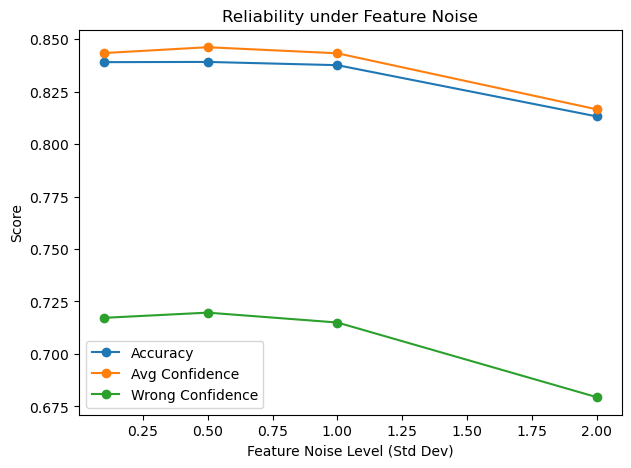

In [15]:
# FEATURE NOISE RELIABILITY EXPERIMENT
# ADD NOISE AND EVALUATE
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Identify numeric columns
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
noise_levels = [0.1, 0.5, 1.0, 2.0]
records = []

for noise in noise_levels:
    # Copy training data
    X_noisy = X_train.copy()

    # Add Gaussian noise to numeric features
    X_noisy[num_cols] = X_noisy[num_cols] + np.random.normal(0, noise, X_noisy[num_cols].shape)

    # Train model
    m = LogisticRegression(max_iter=1000)
    m.fit(X_noisy, y_train)

    # Predict
    probs_n = m.predict_proba(X_test)
    preds_n = probs_n.argmax(axis=1)
    conf_n = probs_n.max(axis=1)
    accuracy_n = (preds_n == y_test).mean()
    avg_conf = conf_n.mean()
    wrong_conf = conf_n[preds_n != y_test].mean()
    records.append([noise, accuracy_n, avg_conf, wrong_conf])

feature_noise_results = pd.DataFrame(records,columns=["Noise Std","Accuracy","Avg Confidence","Wrong Confidence"])
feature_noise_results


# PLOT BEHAVIOUR
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(feature_noise_results["Noise Std"], feature_noise_results["Accuracy"], marker='o', label="Accuracy")
plt.plot(feature_noise_results["Noise Std"], feature_noise_results["Avg Confidence"], marker='o', label="Avg Confidence")
plt.plot(feature_noise_results["Noise Std"], feature_noise_results["Wrong Confidence"], marker='o', label="Wrong Confidence")

plt.xlabel("Feature Noise Level (Std Dev)")
plt.ylabel("Score")
plt.title("Reliability under Feature Noise")
plt.legend()
plt.savefig("Reliability under Feature Noise.png", dpi=300, bbox_inches="tight")
plt.show()

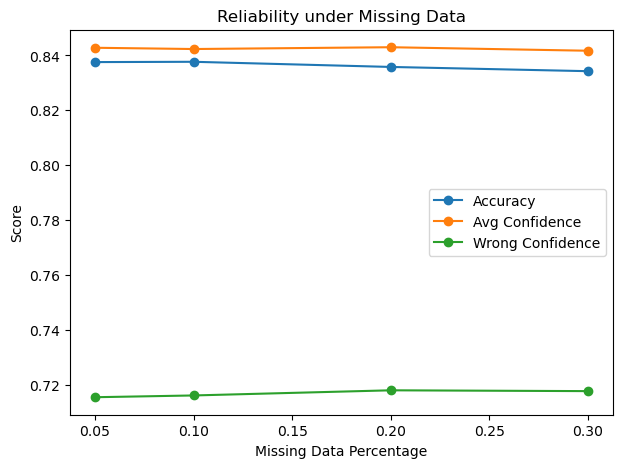

In [16]:
# MISSING DATA RELIABILITY EXPERIMENT
# REMOVE VALUES AND TRAIN

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

missing_levels = [0.05, 0.10, 0.20, 0.30]
records = []

for miss in missing_levels:
    # Copy dataset and convert to float (allows NaN safely)
    X_missing = X_train.copy().astype(float)

    # Randomly remove values
    mask = np.random.rand(*X_missing.shape) < miss
    X_missing[mask] = np.nan

    # Fill missing values
    imputer = SimpleImputer(strategy='most_frequent')
    X_filled = pd.DataFrame(imputer.fit_transform(X_missing), columns=X_train.columns)

    # Train model
    m = LogisticRegression(max_iter=1000)
    m.fit(X_filled, y_train)

    # Evaluate
    probs_m = m.predict_proba(X_test)
    preds_m = probs_m.argmax(axis=1)
    conf_m = probs_m.max(axis=1)
    accuracy_m = (preds_m == y_test).mean()
    avg_conf = conf_m.mean()
    wrong_conf = conf_m[preds_m != y_test].mean()
    records.append([miss, accuracy_m, avg_conf, wrong_conf])

missing_results = pd.DataFrame(records,columns=["Missing %","Accuracy","Avg Confidence","Wrong Confidence"])
missing_results


# PLOT BEHAVIOUR
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(missing_results["Missing %"], missing_results["Accuracy"], marker='o', label="Accuracy")
plt.plot(missing_results["Missing %"], missing_results["Avg Confidence"], marker='o', label="Avg Confidence")
plt.plot(missing_results["Missing %"], missing_results["Wrong Confidence"], marker='o', label="Wrong Confidence")

plt.xlabel("Missing Data Percentage")
plt.ylabel("Score")
plt.title("Reliability under Missing Data")
plt.legend()
plt.savefig("Reliability under Missing Data.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# DISTRIBUTION SHIFT RELAIABILITY EXPERIMENT 
# CREATE SHIFTED DATASETS

# Train on younger population
train_mask = df['age'] < 40

# Test on older population
test_mask = df['age'] >= 40

X_train_shift = X[train_mask]
y_train_shift = y[train_mask]
X_test_shift = X[test_mask]
y_test_shift = y[test_mask]

print("Train size:", X_train_shift.shape)
print("Test size :", X_test_shift.shape)


# TRAIN AND EVALUATE
from sklearn.linear_model import LogisticRegression

# Train model
shift_model = LogisticRegression(max_iter=1000)
shift_model.fit(X_train_shift, y_train_shift)

# Predict
probs_shift = shift_model.predict_proba(X_test_shift)
preds_shift = probs_shift.argmax(axis=1)
conf_shift = probs_shift.max(axis=1)
accuracy_shift = (preds_shift == y_test_shift).mean()
avg_conf_shift = conf_shift.mean()
wrong_conf_shift = conf_shift[preds_shift != y_test_shift].mean()

print("Accuracy:", accuracy_shift)
print("Avg Confidence:", avg_conf_shift)
print("Wrong Confidence:", wrong_conf_shift)

Train size: (25407, 104)
Test size : (19815, 104)
Accuracy: 0.7720918496088821
Avg Confidence: 0.7884369471365689
Wrong Confidence: 0.7046500400769072


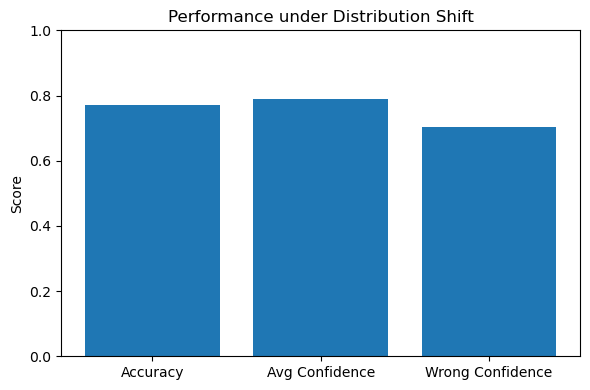

In [18]:
# PERFORMANCE UNDER DISTRIBUTION SHIFT
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Avg Confidence", "Wrong Confidence"]
values = [accuracy_shift, avg_conf_shift, wrong_conf_shift]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)

plt.ylim(0,1)
plt.title("Performance under Distribution Shift")
plt.ylabel("Score")

plt.tight_layout()
plt.savefig("Distribution_Shift.png", dpi=300)
plt.show()

In [19]:
# Random Forest Comparison
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict
rf_probs = rf.predict_proba(X_test)
rf_preds = rf_probs.argmax(axis=1)
rf_conf = rf_probs.max(axis=1)

# Metrics
rf_accuracy = (rf_preds == y_test).mean()
rf_avg_conf = rf_conf.mean()
rf_wrong_conf = rf_conf[rf_preds != y_test].mean()

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Avg Confidence:", rf_avg_conf)
print("Wrong Confidence:", rf_wrong_conf)


# COMPARE WITH LOGISTIC REGRESSION

print("\nLogistic Regression Results")
print("Accuracy:", accuracy)
print("Avg Confidence:", confidence.mean())
print("Wrong Confidence:", confidence[preds != y_test].mean())

Random Forest Results
Accuracy: 0.8519624101713654
Avg Confidence: 0.8672606925689015
Wrong Confidence: 0.7137346278317152

Logistic Regression Results
Accuracy: 0.8392482034273079
Avg Confidence: 0.8549526967775969
Wrong Confidence: 0.7109670830402578


In [20]:
# Final Reliability Score 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Logistic Regression 
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_probs = lr_model.predict_proba(X_test)
lr_preds = lr_probs.argmax(axis=1)
lr_conf = lr_probs.max(axis=1)
lr_accuracy = (lr_preds == y_test).mean()
lr_overconfidence = lr_conf[lr_preds != y_test].mean()
lr_conf_gap = lr_conf.mean() - lr_accuracy


# Random Forest 
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_probs = rf_model.predict_proba(X_test)
rf_preds = rf_probs.argmax(axis=1)
rf_conf = rf_probs.max(axis=1)
rf_accuracy = (rf_preds == y_test).mean()
rf_overconfidence = rf_conf[rf_preds != y_test].mean()
rf_conf_gap = rf_conf.mean() - rf_accuracy


# Summary Table 
summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Overconfidence Score": [lr_overconfidence, rf_overconfidence],
    "Confidence Gap": [lr_conf_gap, rf_conf_gap]})
summary.to_csv("Model Comparison Table.csv", index=False)
summary

,Model,Accuracy,Overconfidence Score,Confidence Gap
0,Logistic Regression,0.839469,0.718124,0.004392
1,Random Forest,0.851962,0.713735,0.015298


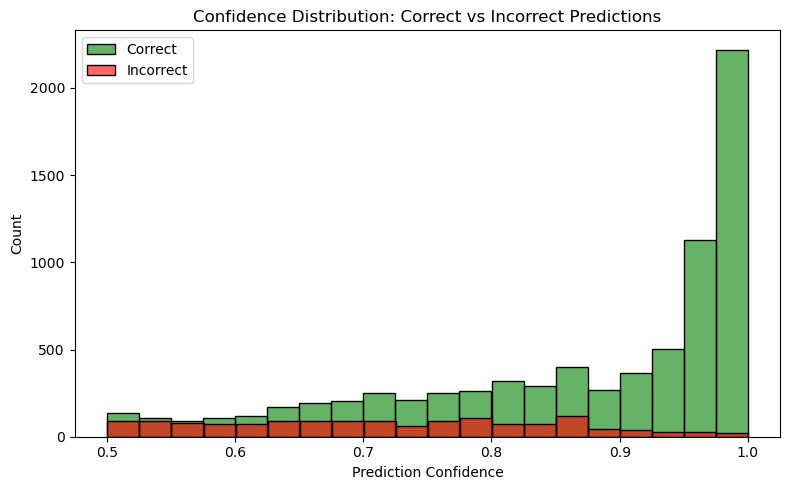

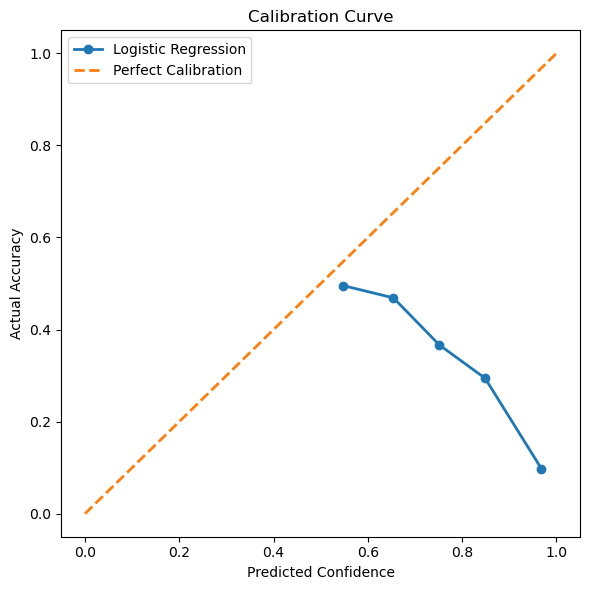

In [21]:
# CONFIDENCE VS CORRECTNESS PLOT

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(lr_conf[lr_preds == y_test], bins=20, color="green", alpha=0.6, label="Correct")
sns.histplot(lr_conf[lr_preds != y_test], bins=20, color="red", alpha=0.6, label="Incorrect")

plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.title("Confidence Distribution: Correct vs Incorrect Predictions")
plt.legend()
plt.tight_layout()
plt.savefig("Final Confidence Distribution Plot.png", dpi=300, bbox_inches="tight")
plt.show()

# FINAL CALIBRATION CURVE

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, lr_conf, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label="Logistic Regression")
plt.plot([0,1],[0,1],'--', linewidth=2, label="Perfect Calibration")

plt.xlabel("Predicted Confidence")
plt.ylabel("Actual Accuracy")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig("Final Calibration Curve.png", dpi=300, bbox_inches="tight")
plt.show()

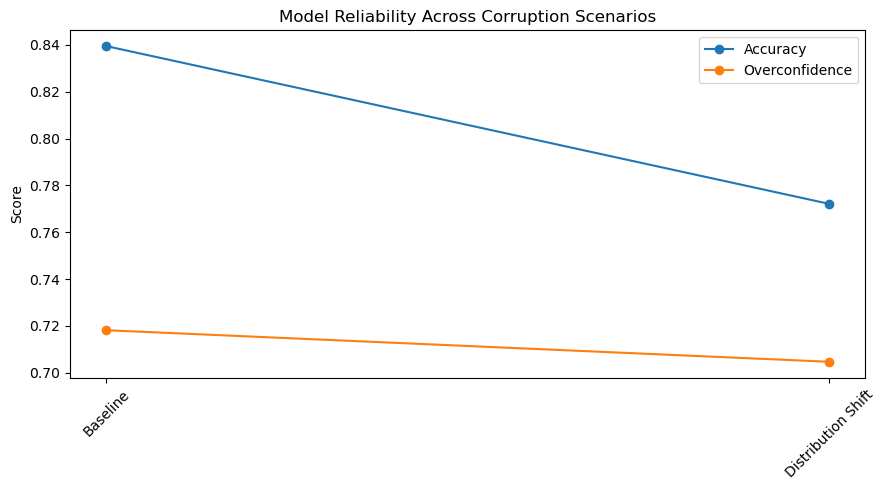

In [22]:
# FINAL CORRUPTION SUMMARY PLOT

corruption_summary = pd.DataFrame({
    "Experiment": ["Baseline", "Distribution Shift"],
    "Accuracy": [lr_accuracy, accuracy_shift],
    "Overconfidence": [lr_overconfidence,wrong_conf_shift]})

corruption_summary

# VISULAIZING
plt.figure(figsize=(9,5))

plt.plot(corruption_summary["Experiment"], corruption_summary["Accuracy"],
         marker='o', label="Accuracy")
plt.plot(corruption_summary["Experiment"], corruption_summary["Overconfidence"],
         marker='o', label="Overconfidence")

plt.xticks(rotation=45)
plt.ylabel("Score")
plt.title("Model Reliability Across Corruption Scenarios")
plt.legend()
plt.tight_layout()
plt.savefig("Model Reliability Across Corruption Scenarios.png", dpi=300, bbox_inches="tight")
plt.show()

# Final Conclusions

## 1. Summary of Findings

This study investigated the relationship between prediction confidence and correctness under controlled corruption scenarios using the UCI Adult Income dataset.

Across multiple experiments, consistent patterns emerged:

- Prediction confidence often remained high even when accuracy decreased.
- Incorrect predictions frequently exhibited high confidence values.
- Calibration curves showed systematic overconfidence.
- Distribution shift caused performance degradation without proportional reduction in confidence.

This study investigated the relationship between prediction confidence and correctness under controlled corruption scenarios using the UCI Adult Income dataset.


## 2. Model Comparison

Random Forest achieved higher accuracy than Logistic Regression but exhibited a larger confidence gap. Both models maintained high confidence in incorrect predictions.

Higher predictive performance does not imply higher reliability.


## 3. Core Reliability Insight

Overconfidence remained consistently high across corruption scenarios, defined as:

Overconfidence = mean(confidence | incorrect prediction)

Therefore:

- Confidence is poorly aligned with correctness.
- Models detect contradiction better than uncertainty.
- Overconfidence persists under distribution shift.


## 4. Final Statement

This study demonstrates that machine learning models can remain highly confident even when wrong. Therefore, reliability evaluation must extend beyond traditional accuracy metrics and explicitly analyze confidence behavior.